<a href="https://colab.research.google.com/github/Juni0rResearcher/AdvancedRobotics/blob/main/HW2_LinearKalmanFilter/HW2_LinearKalmanFilter_Iuzhanin_Andrei.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Home assignment 2 LinearKalmanFilter-for-SmartphoneSensors

**Студент:** Южанин Андрей

**Задача:** Используя смартфон, пройти определенную дистанцию на улице, записать данные и с помощью фильтра Калмана объединить показания GPS и акселерометра для точной оценки пройденного пути.

**Данные:** Дата собран с помощью записи показаний с датчиков на смартфоне с IOS через Physics Toolbox Sensor Suite. Было пройдено расстояние 1 км в городских условиях. Были записаны показания:
-  GPS (Location): Широта (Latitude), Долгота (Longitude).
-  Linear Accelerometer: Ускорение по осям X, Y, Z без учета гравитации

**Реализация в Jupyter/Colab:**
1. Загрузка данных: Импортирован CSV файл с записанными данными. Построен путь, рассчитана дистанция по траектории, измеренной чисто по GPS с использованием формулы Haversine.
2. Определены параметры шума (Hint):
  - std_acc (шум процесса): произведена оценка стандартного отклонения акселерометра. Был взят участок данных, где телефон двигался равномерно.
  - std_meas (шум измерения): выполнена оценка точность GPS в стабильном состоянии.
3. Фильтр Калмана:
  - Реализован линейный фильтр Калмана.
  - Вектор состояния: 𝒙 = 𝒑𝒐𝒔𝒊𝒕𝒊𝒐𝒏, 𝒗𝒆𝒍𝒐𝒄𝒊𝒕𝒚 𝑻.
  - Вход управления (u): Данные линейного акселерометра (спроецированные на направление движения).
4. Результат:
  - Построен сравнительный график измеренной дистанции (GPS) с предсказанной дистанцией (KF).

## 1. Импорт библиотек и загрузка CSV файла

### 1.1 Импорт библиотек

In [ ]:
%%capture
!pip install gdown -q

In [1]:
import numpy as np
import pandas as pd
import gdown
import math
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
import warnings

### 1.2 Загрузка файла csv с Google Drive

Файл загружается по прямой ссылке. Результат успешной загрузки демонстрируется выводом первых 5 строк.

In [ ]:
url = 'https://drive.google.com/file/d/1gFDPVxT4EK4DT6R3cPtJKYqX3MrxV0y5/view?usp=sharing'

file_id = url.split('/d/')[1].split('/')[0]
direct_url = f'https://drive.google.com/uc?export=download&id={file_id}'

df = pd.read_csv(direct_url)
print(df.head())

                       time      ax      ay      az   latitude  longitude  \
0  2026-03-10T14:37:58.186Z -0.4112  1.1605  1.6310  55.753277  48.740667   
1  2026-03-10T14:37:58.195Z -0.5224  1.4438  1.0339  55.753277  48.740667   
2  2026-03-10T14:37:58.205Z -0.1989  1.6354  0.5159  55.753277  48.740667   
3  2026-03-10T14:37:58.215Z  0.2407  1.8423  0.2662  55.753277  48.740667   
4  2026-03-10T14:37:58.225Z  0.6342  1.9003  0.2624  55.753277  48.740667   

   altitude   speed  
0  193.1579  1.2763  
1  193.1579  1.2763  
2  193.1579  1.2763  
3  193.1579  1.2763  
4  193.1579  1.2763  


## 2. Вспомогательные функции

### 2.1. Функция рассчета расстояния по формуле Haversine



Формула гаверсинусов (Haversine formula) — это уравнение, используемое в навигации для вычисления кратчайшего расстояния между двумя точками на поверхности сферы (например, Земли), зная их долготу и широту.
По двум координатам GPS, с помощью этой формулы можно вычислить, сколько километров между начальной и конечной точкой «по прямой» (по дуге земного шара), а не через толщу Земли.

\begin{equation}
\begin{split}
a &= \sin^2\left(\frac{\phi_2 - \phi_1}{2}\right) + \cos\phi_1 \cos\phi_2 \sin^2\left(\frac{\lambda_2 - \lambda_1}{2}\right) \\
c &= 2 \cdot \operatorname{atan2}\left(\sqrt{a}, \sqrt{1-a}\right) \\
d &= R \cdot c
\end{split}
\end{equation}

где:
\begin{equation}
\begin{split}
\phi_1, \phi_2 & \text{- широты точек (в радианах)} \\
\lambda_1, \lambda_2 & \text{- долготы точек (в радианах)} \\
R & \text{- радиус Земли ($\approx 6371$ км)} \\
d & \text{- искомое расстояние}
\end{split}
\end{equation}

In [ ]:
def calculate_total_distance(df, lat_col='latitude', lon_col='longitude'):
    '''
    Функция для вычисления общего расстояния от начальной до конечной точки датасета по формуле Haversine
    '''
    R = 6372800

    # Конвертируем все координаты в радианы
    lat = np.radians(df[lat_col].values)
    lon = np.radians(df[lon_col].values)

    # Сдвиг на 1 для получения пар (точка i и точка i+1)
    dlat = lat[1:] - lat[:-1]
    dlon = lon[1:] - lon[:-1]

    # Формула Haversine для всех пар сразу
    a = np.sin(dlat/2)**2 + np.cos(lat[:-1]) * np.cos(lat[1:]) * np.sin(dlon/2)**2
    distances = 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return distances.sum()

### 2.2 Функция поиска участка с минимальным шумом по данным

Создается скользящее окно по всему датасету. Если скорость меньше 0,1 м/с, разброс координат до 1 метра, то принимаем этот участок устойчивым состоянием и оцениваем на нем шум

In [2]:
def find_cleaner_stationary(df, min_points=50):
    """Ищет участок с минимальным шумом"""

    best_score = np.inf
    best_segment = None

    # Скользящее окно по всему датасету
    for start in range(0, len(df) - min_points, min_points // 2):
        segment = df.iloc[start:start + min_points].copy()

        # Скорость
        if segment['speed'].max() > 0.1:
            continue

        # Разброс координат до 1 метра
        lat_std = segment['latitude'].std() * 111000
        lon_std = segment['longitude'].std() * 111000 * np.cos(np.radians(segment['latitude'].mean()))
        if lat_std > 5.0 or lon_std > 5.0:
            continue

        # Оценка шума акселерометра
        temp = segment.copy()
        for col in ['ax', 'ay', 'az']:
            temp[col] = temp[col].rolling(5, center=True).mean()

        std_ax = temp['ax'].std()
        std_ay = temp['ay'].std()
        std_az = (temp['az'] - 9.81).std()
        score = np.mean([std_ax, std_ay, std_az])

        if score < best_score:
            best_score = score
            best_segment = segment.copy()

    return best_segment

### 2.4 Функция преобразоваиня широты/долготы в метры

In [ ]:
def gps_to_local_meters(df):
    """Перевод широты/долготы в метры относительно точки (lat0, lon0)"""
    lat0, lon0 = df['latitude'].iloc[0], df['longitude'].iloc[0]

    R = 6372800
    lat_rad = np.radians(df['latitude'] - lat0)
    lon_rad = np.radians(df['longitude'] - lon0) * np.cos(np.radians(lat0))

    x = R * lat_rad
    y = R * lon_rad

    return x, y

### 2.5 Фильтр Калмана

Фильтр Калмана (Kalman Filter) — это алгоритм, который использует ряд наблюдений, содержащих статистический шум и неточности, и производит оценки неизвестных переменных, которые оказываются более точными, чем оценки, основанные на одном измерении.

Он комбинирует предсказание (как система должна себя вести по модели) и измерение (что говорят датчики), взвешивая их в зависимости от того, насколько мы доверяем каждому источнику.

Предсказание

\begin{aligned}
\hat{\mathbf{x}}_{k|k-1} &= \mathbf{F}_k \hat{\mathbf{x}}_{k-1|k-1} + \mathbf{B}_k \mathbf{u}_k \\
\mathbf{P}_{k|k-1} &= \mathbf{F}_k \mathbf{P}_{k-1|k-1} \mathbf{F}_k^\top + \mathbf{Q}_k
\end{aligned}

Коррекция

\begin{aligned}
\mathbf{K}_k &= \mathbf{P}_{k|k-1} \mathbf{H}_k^\top \left( \mathbf{H}_k \mathbf{P}_{k|k-1} \mathbf{H}_k^\top + \mathbf{R}_k \right)^{-1} \\
\hat{\mathbf{x}}_{k|k} &= \hat{\mathbf{x}}_{k|k-1} + \mathbf{K}_k \left( \mathbf{z}_k - \mathbf{H}_k \hat{\mathbf{x}}_{k|k-1} \right) \\
\mathbf{P}_{k|k} &= \left( \mathbf{I} - \mathbf{K}_k \mathbf{H}_k \right) \mathbf{P}_{k|k-1}
\end{aligned}

где:

$\hat{\mathbf{x}}_{k|k-1}$ - Предсказанное состояние

$\hat{\mathbf{x}}_{k|K}$ - Обновленное состояние

$\mathbf{P}_{k|k-1}$ - Предсказанная ковариация

$\mathbf{P}_{k|k}$ - Обновленная ковариация

$\mathbf{F}$ - матрица перехода

$\mathbf{H}$ - матрица наблюдений

$\mathbf{Q}$ - шум процесса

$\mathbf{R}$ - шум измерений

$\mathbf{K}$ - gain

$\mathbf{z}$ - измерение

In [ ]:
class KalmanFilter1D:
    """
    Линейный фильтр Калмана для 1D трекинга.
    Состояние: [position, velocity]
    Управление: acceleration
    Измерение: position (GPS)
    """

    def __init__(self, dt, std_acc, std_meas, x0=None):
        """
        dt: время между измерениями (сек)
        std_acc: шум процесса (акселерометр), м/с²
        std_meas: шум измерения (GPS), м
        x0: начальное состояние [pos, vel]
        """
        self.dt = dt

        # Матрицы
        self.F = np.array([[1, dt],
                          [0, 1]])

        self.B = np.array([0.5 * dt**2,
                          dt])

        self.H = np.array([1, 0])  # измеряем только позицию

        # Ковариации
        self.Q = np.array([[0.25*dt**4, 0.5*dt**3],
                          [0.5*dt**3, dt**2]]) * (std_acc ** 2)

        self.R = std_meas ** 2  # скаляр

        # Инициализация состояния
        if x0 is None:
            self.x = np.array([0, 0])  # [pos, vel]
        else:
            self.x = np.array(x0)

        # Ковариация состояния
        self.P = np.eye(2) * 10  # большая начальная неопределённость

    def predict(self, u):
        """Шаг прогноза (по акселерометру)"""
        # Прогноз состояния
        self.x = self.F @ self.x + self.B * u

        # Прогноз ковариации
        self.P = self.F @ self.P @ self.F.T + self.Q

        return self.x.copy()

    def update(self, z):
        """Шаг коррекции (по GPS)"""
        if z is None or np.isnan(z):
            return self.x.copy()  # нет измерения — только прогноз

        # Инновация (разница между измерением и прогнозом)
        y = z - self.H @ self.x

        # Ковариация инновации
        S = self.H @ self.P @ self.H.T + self.R

        # Коэффициент Калмана
        K = self.P @ self.H.T / S

        # Коррекция состояния
        self.x = self.x + K * y

        # Коррекция ковариации
        self.P = (np.eye(2) - K @ self.H) @ self.P

        return self.x.copy()

    def run(self, measurements, controls, dt_array=None):
        """
        Запуск фильтра на всём наборе данных.
        measurements: массив GPS-позиций (в метрах)
        controls: массив ускорений (в м/с²)
        dt_array: массив Δt для каждого шага (опционально)
        """
        n = len(measurements)
        states = np.zeros((n, 2))  # [pos, vel] для каждого шага
        predictions = np.zeros((n, 2))

        for i in range(n):
            # Если Δt меняется — обновляем матрицы
            if dt_array is not None and dt_array[i] > 0:
                self.dt = dt_array[i]
                self.F = np.array([[1, self.dt], [0, 1]])
                self.B = np.array([0.5 * self.dt**2, self.dt])
                self.Q = np.array([[0.25*self.dt**4, 0.5*self.dt**3],
                                  [0.5*self.dt**3, self.dt**2]]) * (self.Q[1,1] / self.dt**2)

            # Прогноз
            pred = self.predict(controls[i])
            predictions[i] = pred

            # Коррекция
            state = self.update(measurements[i])
            states[i] = state

        return states, predictions

### 2.6 Расчет пройденного пути

In [ ]:
def calculate_cumulative_distance(df, x_m, y_m):
    """Расчет кумулятивного пройденного пути"""
    distances = np.zeros(len(df))
    for i in range(1, len(df)):
        dx = x_m.iloc[i] - x_m.iloc[i-1]
        dy = y_m.iloc[i] - y_m.iloc[i-1]
        distances[i] = distances[i-1] + np.sqrt(dx**2 + dy**2)
    return distances

### 2.7 Проецирование ускорения на текущее направление движения

В цикле в каждую единицу времени определяется направление движения по GPS за счет разницы положения в текущий момент времени и предыдущем моментомвремени. Затем, если было совершенно движения, проецируется ускорение на направление движения.

In [ ]:
def project_acceleration_to_motion_direction(df, x_gps, y_gps):
    """Проецирование ускорения на текущее направление движения"""
    acc_projected = np.zeros(len(df))

    for i in range(1, len(df)):
        # Текущее направление движения по GPS
        dx = x_gps.iloc[i] - x_gps.iloc[i-1]
        dy = y_gps.iloc[i] - y_gps.iloc[i-1]
        dist = np.sqrt(dx**2 + dy**2)

        if dist > 0.01:  # порог для определения движения
            dir_x = dx / dist
            dir_y = dy / dist
            # Проецируем ускорение на направление движения
            acc_projected[i] = df['ax'].iloc[i] * dir_x + df['ay'].iloc[i] * dir_y
        else:
            # Если движения нет, используем предыдущее значение или ноль
            acc_projected[i] = acc_projected[i-1] if i > 1 else 0

    return acc_projected

## 3. Запуск проекта

### 3.1 Анализа данных csv

На основе таблицы рассчитыаем общее расстояние

In [ ]:
total_distance= calculate_total_distance(df)
print(f"Общее расстояние: {total_distance:.2f} м ({total_distance/1000:.3f} км)")

Общее расстояние: 1028.52 м (1.029 км)


Визуализируем на графике пройденный путь

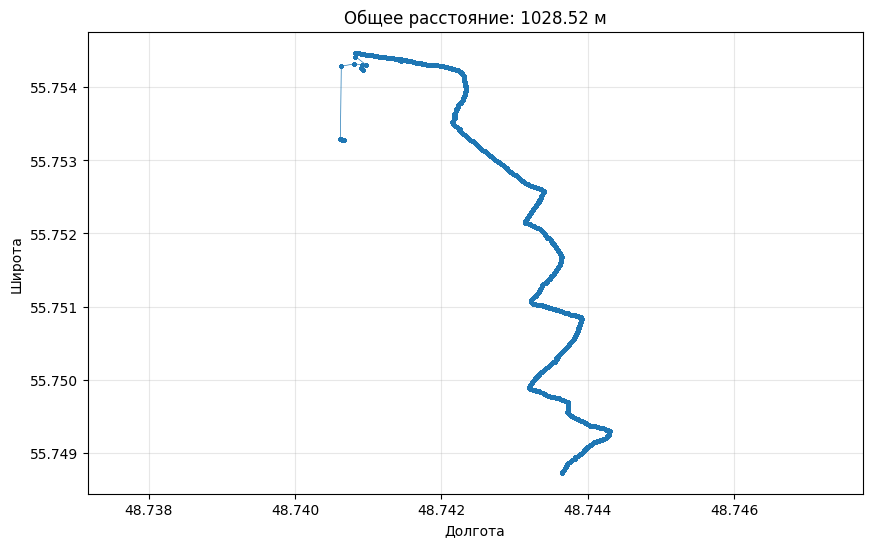

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df['longitude'], df['latitude'], '-o', markersize=2, linewidth=0.5)
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.title(f'Общее расстояние: {total_distance:.2f} м')
plt.grid(alpha=0.3)
plt.axis('equal')
plt.show()

### 3.2 Определение шума

Для определения шума рассчитаем стандартное отклонение акселерометра и данных gps в стабильном состоянии

In [ ]:
# Находим участок, где телефон находился неподвижно (скорость < 0.1 м/с)
# Параметры: допустимое изменение координат (в градусах)
MAX_LAT_DIFF = 0.00001
MAX_LON_DIFF = 0.00001
stationary = df[
    (df['speed'] < 0.1) &
    (df['latitude'].diff().abs().fillna(0) < MAX_LAT_DIFF) &
    (df['longitude'].diff().abs().fillna(0) < MAX_LON_DIFF)
].copy()

print(f"Найдено стационарных точек: {len(stationary)} из {len(df)}")
stationary.head()

Найдено стационарных точек: 1857 из 56197


,time,ax,ay,az,latitude,longitude,altitude,speed
73,2026-03-10T14:37:58.915Z,-0.2709,-0.3639,-0.9167,55.753282,48.740654,188.1424,0.0
74,2026-03-10T14:37:58.925Z,0.0360,0.4013,0.5646,55.753282,48.740654,188.1424,0.0
75,2026-03-10T14:37:58.935Z,0.6079,0.8178,1.3757,55.753282,48.740654,188.1424,0.0
76,2026-03-10T14:37:58.945Z,1.0303,0.9030,1.9034,55.753282,48.740654,188.1424,0.0
77,2026-03-10T14:37:58.955Z,1.2193,0.8260,2.5384,55.753282,48.740654,188.1424,0.0


In [ ]:
std_ax = stationary['ax'].std()
std_ay = stationary['ay'].std()
std_az = (stationary['az'] - 9.81).std()

print(f"\nstd_acc по осям:")
print(f"   ax: {std_ax:.4f} м/с^2")
print(f"   ay: {std_ay:.4f} м/с^2")
print(f"   az: {std_az:.4f} м/с^2")


std_acc по осям:
   ax: 1.8546 м/с^2
   ay: 1.1885 м/с^2
   az: 2.3743 м/с^2


Получаем довольно высокое стандартное отклонение, попробуем найти более стабильный участок, применив строгие фильтры:
- скорость <0.05;
- разброс координат до 1 метра

Применим более строгий поиск с помощью функции `clean_stat`, вычислим погрешность ускорений **std_acc**

In [ ]:
clean_stat = find_cleaner_stationary(df, 100)

std_ax = clean_stat['ax'].std()
std_ay = clean_stat['ay'].std()
std_az = (clean_stat['az'] - 9.81).std()

std_acc = max(std_ax, std_ay, std_az)

print(f"std_acc по осям:")
print(f"   ax: {std_ax:.4f} м/с2")
print(f"   ay: {std_ay:.4f} м/с2")
print(f"   az: {std_az:.4f} м/с2")
print(f"\nstd_acc итоговый принимаем максимальный: {std_acc:.4f} м/с2")

std_acc по осям:
   ax: 0.2150 м/с2
   ay: 0.2301 м/с2
   az: 0.1658 м/с2

std_acc итоговый принимаем максимальный: 0.2301 м/с2


Рассчитаем погрешность измерений std_meas в стабильном состоянии

In [ ]:
x_m, y_m = gps_to_local_meters(clean_stat)

std_x = x_m.std()
std_y = y_m.std()
std_meas = np.sqrt(std_x**2 + std_y**2)

print(f"std_meas по осям:")
print(f"   X: {std_x:.3f} м")
print(f"   Y: {std_y:.3f} м")
print(f"\nСтандартное отклонение координат std_meas: {std_meas:.3f}")

std_meas по осям:
   X: 0.021 м
   Y: 0.006 м

Стандартное отклонение координат std_meas: 0.022


### 3.3 Проекция ускорения на направление движения

In [ ]:
x_gps, y_gps = gps_to_local_meters(df)
distance_gps = calculate_cumulative_distance(df, x_gps, y_gps)

acceleration_projected = project_acceleration_to_motion_direction(df, x_gps, y_gps)

gravity_compensated = df.copy()
gravity_compensated['az'] = gravity_compensated['az'] - 9.81

### 3.4 Опредление среднего временного интервала
Рассчитываем временные интервалы

In [ ]:
df['time'] = pd.to_datetime(df['time'])
time_diffs = df['time'].diff().dt.total_seconds().values
time_diffs[0] = time_diffs[1] if len(time_diffs) > 1 else 0.01

dt_mean = np.median(time_diffs[time_diffs > 0])
print(f"Средний dt: {dt_mean:.4f} с")

Средний dt: 0.0100 с


### 3.5 Предсказание пути с помощью Фильтра Калмана

In [ ]:
kf = KalmanFilter1D(dt=dt_mean, std_acc=std_acc, std_meas=std_meas, x0=[0, 0])

states, predictions = kf.run(
    measurements=distance_gps,
    controls=acceleration_projected,
    dt_array=time_diffs
)

distance_kf = states[:, 0]
velocity_kf = states[:, 1]

### 3.6 Сравнение измеренной дистанции GPS и предсказанной фильтром Калмана

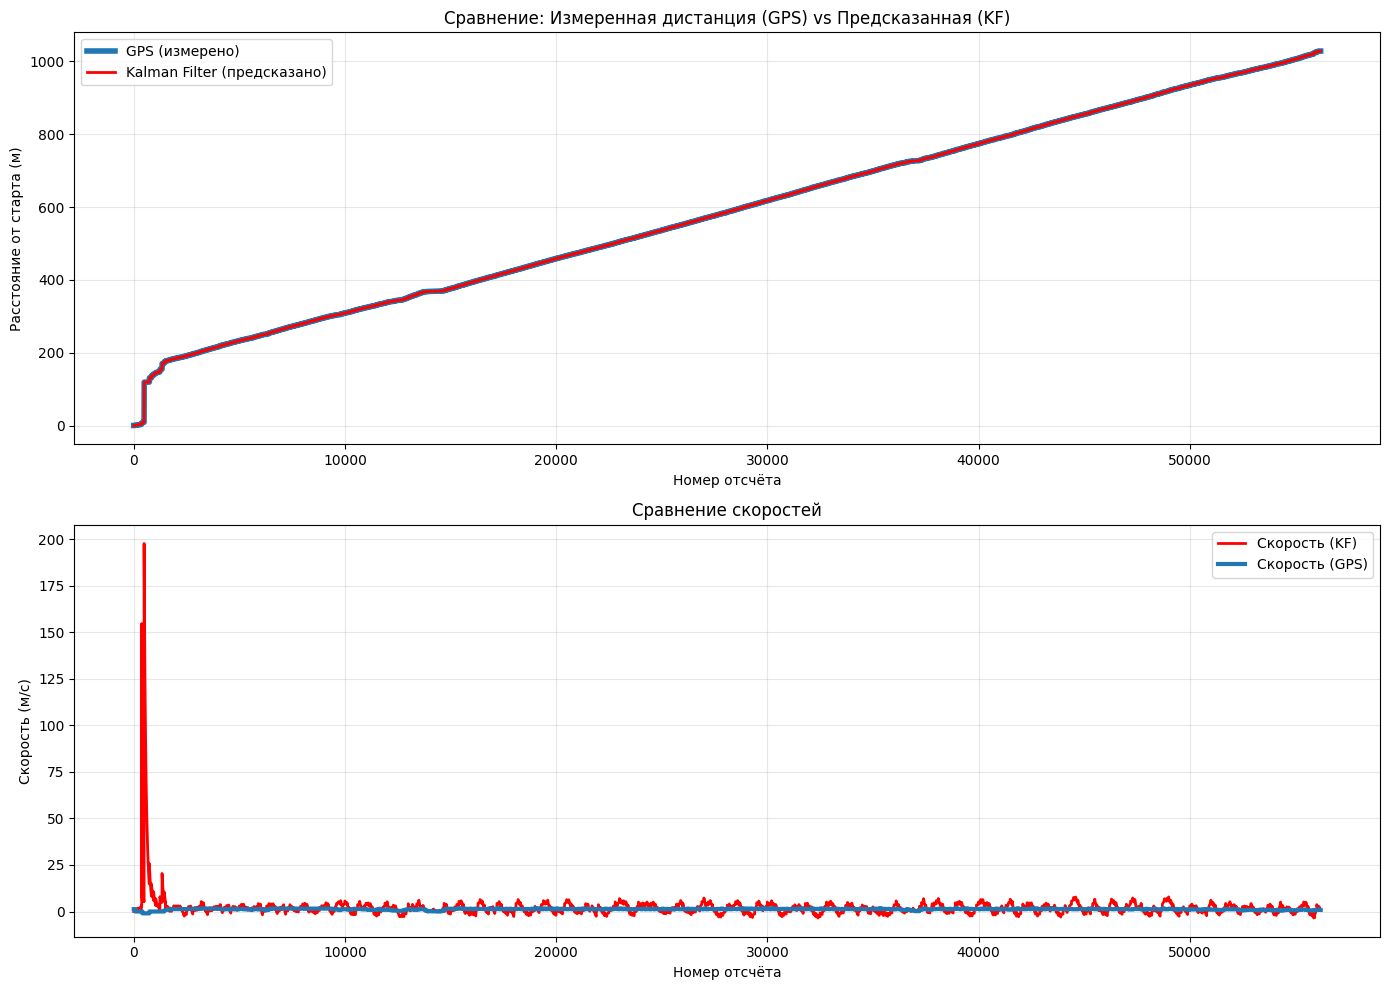

In [ ]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(distance_gps, label='GPS (измерено)', linewidth=4)
plt.plot(distance_kf, label='Kalman Filter (предсказано)', linewidth=2, color='red')
plt.xlabel('Номер отсчёта')
plt.ylabel('Расстояние от старта (м)')
plt.title('Сравнение: Измеренная дистанция (GPS) vs Предсказанная (KF)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(velocity_kf, label='Скорость (KF)', linewidth=2, color='red')
plt.plot(df['speed'].values, label='Скорость (GPS)', linewidth=3)
plt.xlabel('Номер отсчёта')
plt.ylabel('Скорость (м/с)')
plt.title('Сравнение скоростей')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
print(f"РЕЗУЛЬТАТЫ:")

print(f"\nДистанция по GPS: {distance_gps[-1]:.2f} м")
print(f"Дистанция по KF: {distance_kf[-1]:.2f} м")
print(f"Разница в финальной дистанции: {abs(distance_gps[-1] - distance_kf[-1]):.2f} м")
print(f"Средняя абсолютная разница: {np.mean(np.abs(distance_gps - distance_kf)):.2f} м")
print(f"СКО разницы: {np.std(distance_gps - distance_kf):.2f} м")

РЕЗУЛЬТАТЫ:

Дистанция по GPS: 1028.51 м
Дистанция по KF: 1028.51 м
Разница в финальной дистанции: 0.00 м
Средняя абсолютная разница: 0.00 м
СКО разницы: 0.00 м


Таким образом, видим, что фильтр Калмана постоянно корректирует ускорение, для повоторения траектории GPS, при этом предсказания фильтра Калмана практически полностью повторяют показания GPS, что говорит о высоком доверии данным.